As highlighted in the check_synthetic and man_syn_generate notebook, the spatial correlation from the within-event residual extracted using MERA do not match the underlying spatial correlation model (Loth & Baker 2013)

After a discussion with Brendon on 29/05/2024, it was determined that this is most likely due to the fact that mixed effects regression assumes that within-event residuals are independent of each other. This is clearly not the case, as spatial correlations are applied when generating the realisations. 
See the "Considering Spatial Correlation in Mixed-Effects Regression and the Impact on Ground-Motion Models" paper by Jayaram & Baker (2010) for more details on this.

This notebook will attempt to confirm that this is the case for our data!

In [1]:
from pathlib import Path

import einops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spatial_hazard as sh
import sim_ranking as sr
import sha_calc as sha
from mera.mera_pymer4 import run_mera
import ml_tools as mlt
import labelled_data_array as lda

In [2]:
gm_params_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_gm_params/nzgmdb/emp_gm_params.csv")
gm_params = pd.read_csv(gm_params_ffp, index_col=0)

site_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.0/Tables/site_table.csv")
site_df = pd.read_csv(site_ffp, index_col="sta")

In [3]:
# ims = sr.constants.PSA_KEYS
# periods = sr.constants.PERIODS

# sub_ims = ["pSA_0.01", "pSA_0.05", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_2.5", "pSA_5.0", "pSA_7.5", "pSA_10.0"]
# sub_periods = [0.01, 0.05, 0.1, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0]

ims = sub_ims = ["pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_2.5", "pSA_5.0", "pSA_7.5", "pSA_10.0"]
periods = sub_periods = [0.1, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0]


In [4]:
# Compute the distance matrix
dist_matrix = sh.im_dist.calculate_distance_matrix(site_df.index.values.astype(str), site_df)

In [5]:
# Generate realisations
n_rels = 10000
n_events = 5

# events = gm_params.event.unique()[:n_events].astype(str)
events = gm_params.groupby("event").count().iloc[:, 0].sort_values(ascending=False).index[:5].values.astype(str)

gen_im_values = {}
gen_between_values = {}
gen_within_values = {}

for cur_event in events:
    cur_gm_params = gm_params.loc[gm_params.event == cur_event]
    sites = cur_gm_params.site.values.astype(str)

    cur_im_values = []
    cur_between_values, cur_within_values = [], []
    for cur_im in ims:
        cur_im_gm_params = cur_gm_params[
            [f"{cur_im}_mean", f"{cur_im}_std_Inter", f"{cur_im}_std_Intra"]
        ].rename(
            columns={
                f"{cur_im}_mean": "mu",
                f"{cur_im}_std_Inter": "between_event_sigma",
                f"{cur_im}_std_Intra": "within_event_sigma",
            }
        )
        
        cur_im_gm_params[f"between_event_sigma"] = 0.5
        
        R = sh.im_dist.get_corr_matrix(sites, dist_matrix, cur_im)
        # R = np.eye(sites.size)
        
        cur_ims, cur_between, cur_within = sh.im_dist.gen_spatial_im_rels(
            n_rels, R, cur_im_gm_params
        )

        cur_im_values.append(cur_ims)
        cur_between_values.append(cur_between)
        cur_within_values.append(cur_within)

    gen_im_values[cur_event] = lda.LabelledDataArray(
        np.stack(cur_im_values, axis=1),
        axis_labels=[np.arange(n_rels), ims, sites],
        axis_names=["realisation", "IM", "site"],
    )
    gen_between_values[cur_event] = lda.LabelledDataArray(
        np.stack(cur_between_values, axis=1),
        axis_labels=[np.arange(n_rels), ims, sites],
        axis_names=["realisation", "IM", "site"],
    )
    gen_within_values[cur_event] = lda.LabelledDataArray(
        np.stack(cur_within_values, axis=1),
        axis_labels=[np.arange(n_rels), ims, sites],
        axis_names=["realisation", "IM", "site"],
    )

In [6]:
# Run Mera
mera_event_results = {}
mera_within_results = {}
mera_bias_std_results = {}

for ix, cur_event in enumerate(events):
	print(f"Processing event, {ix+1}/{n_events}")
	# Estimate GM Parameters
	cur_im_data = gen_im_values[cur_event]
	cur_site_mean_values = np.mean(cur_im_data, axis=0)
	cur_residuals = lda.LabelledDataArray(cur_im_data - cur_site_mean_values, cur_im_data.axis_labels, axis_names=cur_im_data.axis_names)
	
	# Convert to residual dataframe for mera
	cur_res_df = pd.DataFrame(
	    einops.rearrange(cur_residuals.values, "realisation im site -> (site realisation) im"),
	    columns=ims,
	)
	cur_res_df["site"] = einops.repeat(
	    cur_residuals.axis_labels[2], "site -> (site repeat)", repeat=n_rels
	)
	cur_res_df["rel"] = einops.repeat(
	    np.arange(n_rels),
	    "realisation -> (repeat realisation)",
	    repeat=cur_residuals.labels["site"].size,
	)
	
	# cur_res_df = pd.DataFrame(data=einops.rearrange(cur_residuals.values, "rel site -> (site rel)", site=sites.size), columns=[cur_im])
	# cur_res_df["site"] = np.repeat(sites, n_rels)
	# # cur_res_df["rel"] =  mlt.array_utils.numpy_str_join("", "REL", np.tile(np.arange(n_rels), sites.size).astype(str))
	# cur_res_df["rel"] = np.tile(np.arange(n_rels), sites.size)
	# cur_res_df.index = mlt.array_utils.numpy_str_join("_", cur_res_df["site"].values.astype(str), cur_res_df["rel"].values.astype(str))
	
	event_res_df, within_res, bias_std_df = run_mera(cur_res_df, ims, "rel", "site", compute_site_term=False, verbose=False, assume_biased=False)
	event_res_df.index = event_res_df.index.values.astype(int)
	event_res_df = event_res_df.sort_index()
	
	assert np.all(within_res.index == cur_res_df.index)
	within_res["site"] = cur_res_df["site"]
	within_res["rel"] = cur_res_df["rel"]
	
	within_res_data = lda.LabelledDataArray(
	    einops.rearrange(
	        within_res[ims].values,
	        "(site realisation) im -> realisation site im",
	        realisation=n_rels,
	    ),
	    axis_labels=[np.arange(n_rels), cur_residuals.labels["site"], ims],
	    axis_names=["realisation", "site", "IM"],
	)
	
	mera_event_results[cur_event] = event_res_df
	mera_within_results[cur_event] = within_res_data
	mera_bias_std_results[cur_event] = bias_std_df

Processing event, 1/5
Processing event, 2/5
Processing event, 3/5
Processing event, 4/5
Processing event, 5/5


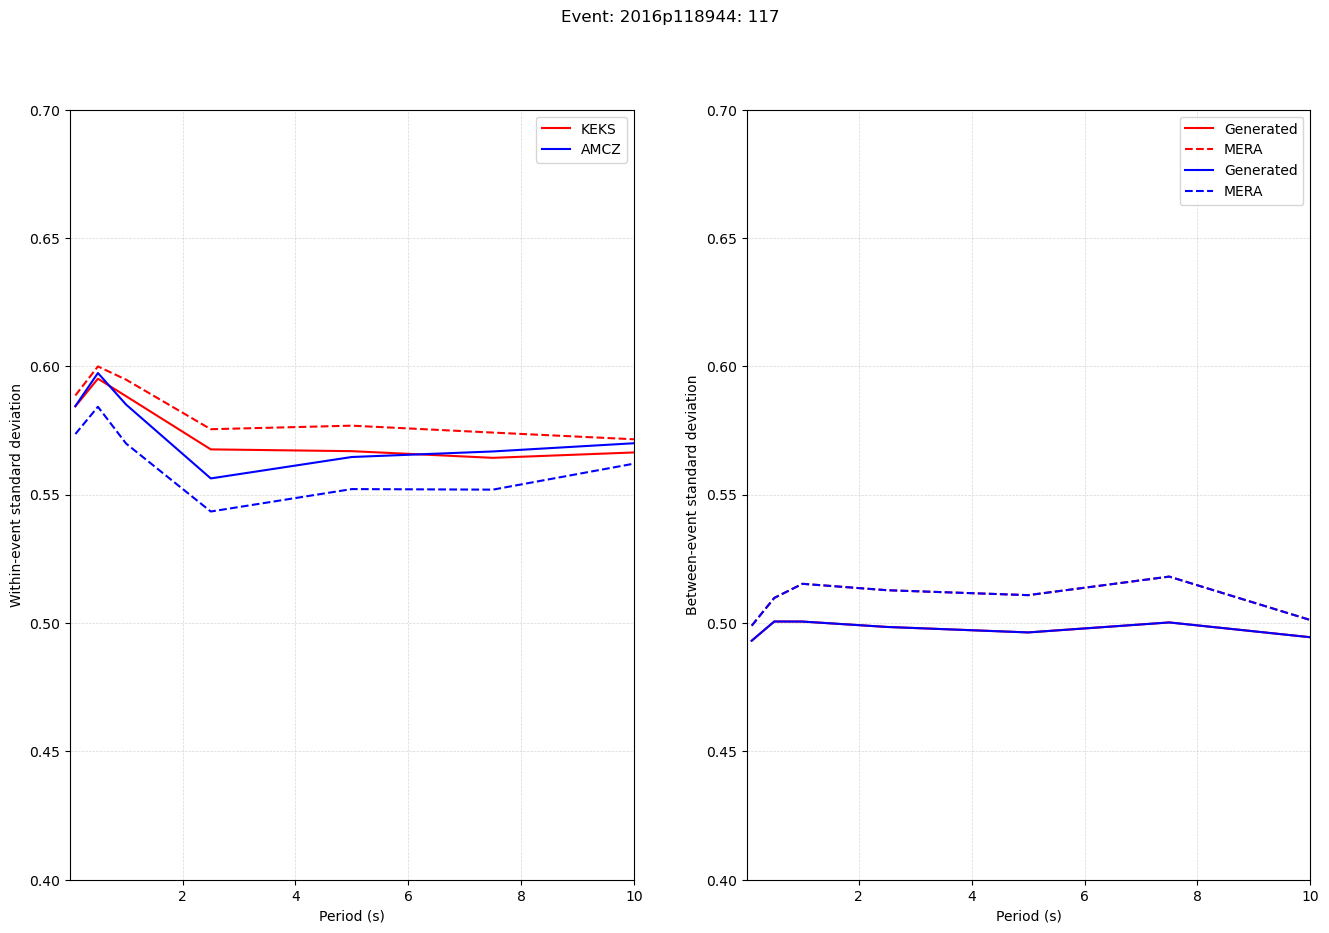

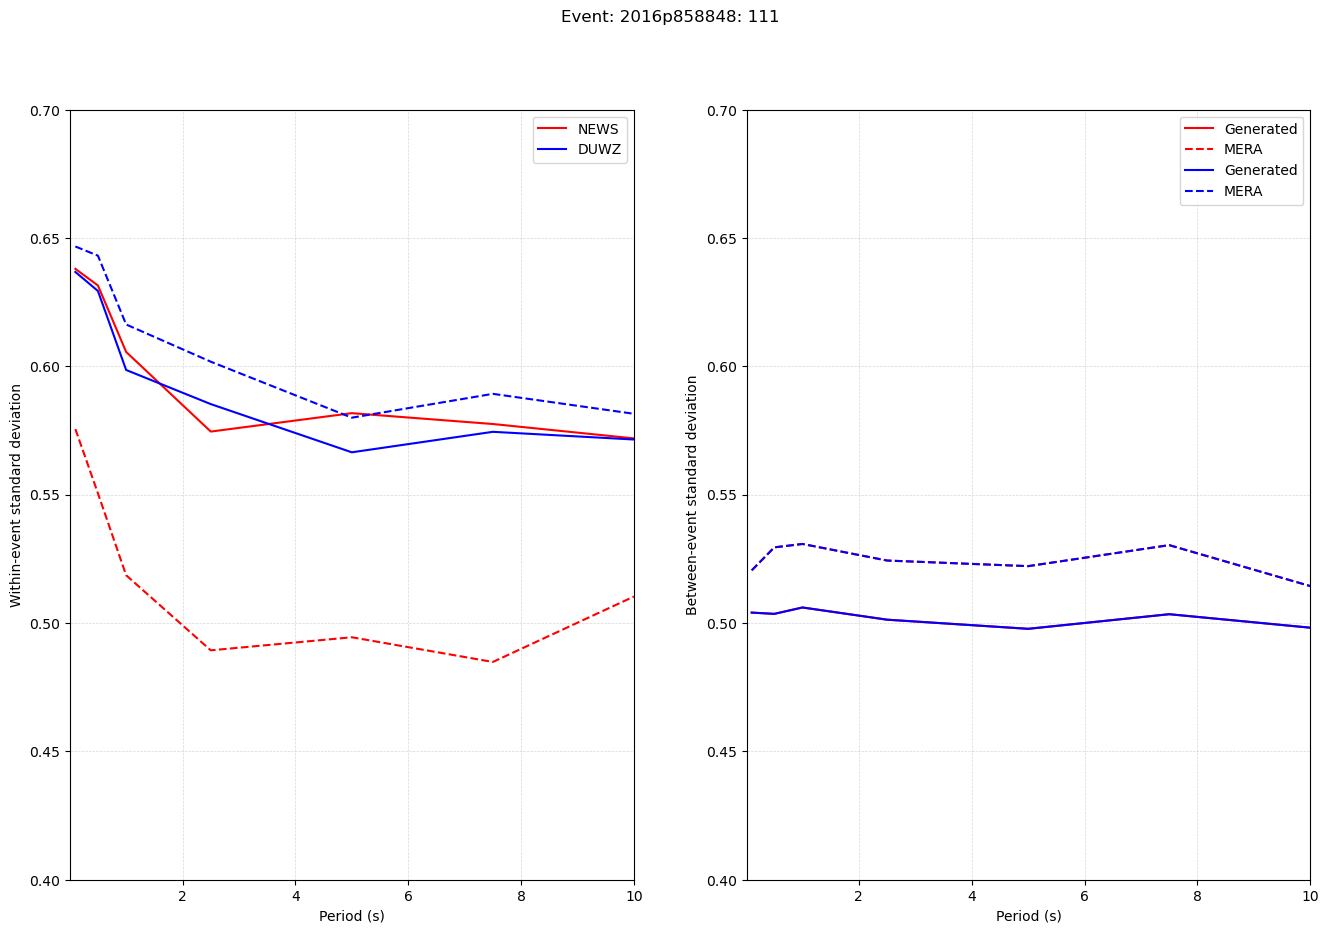

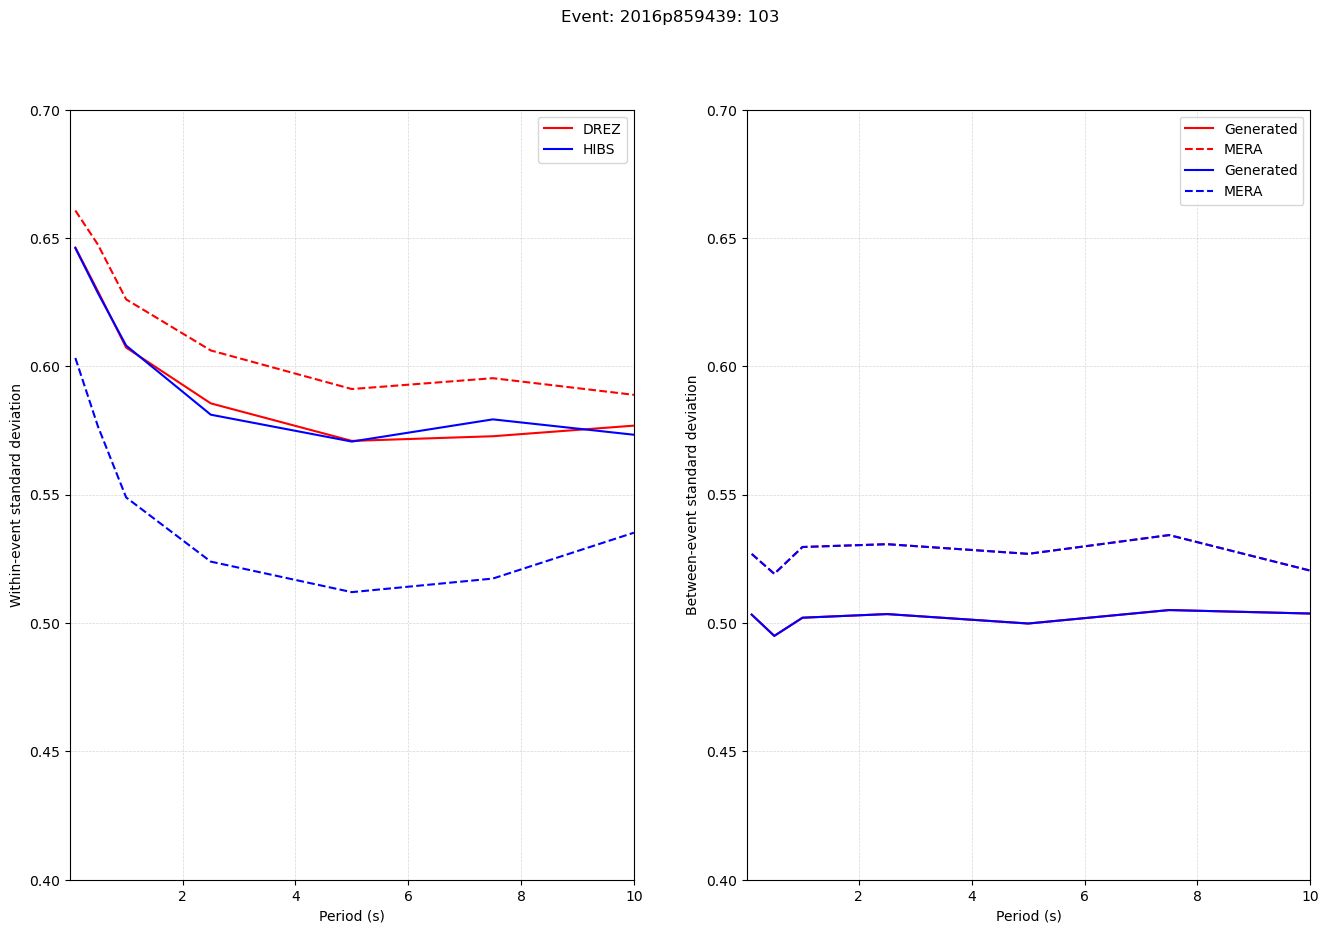

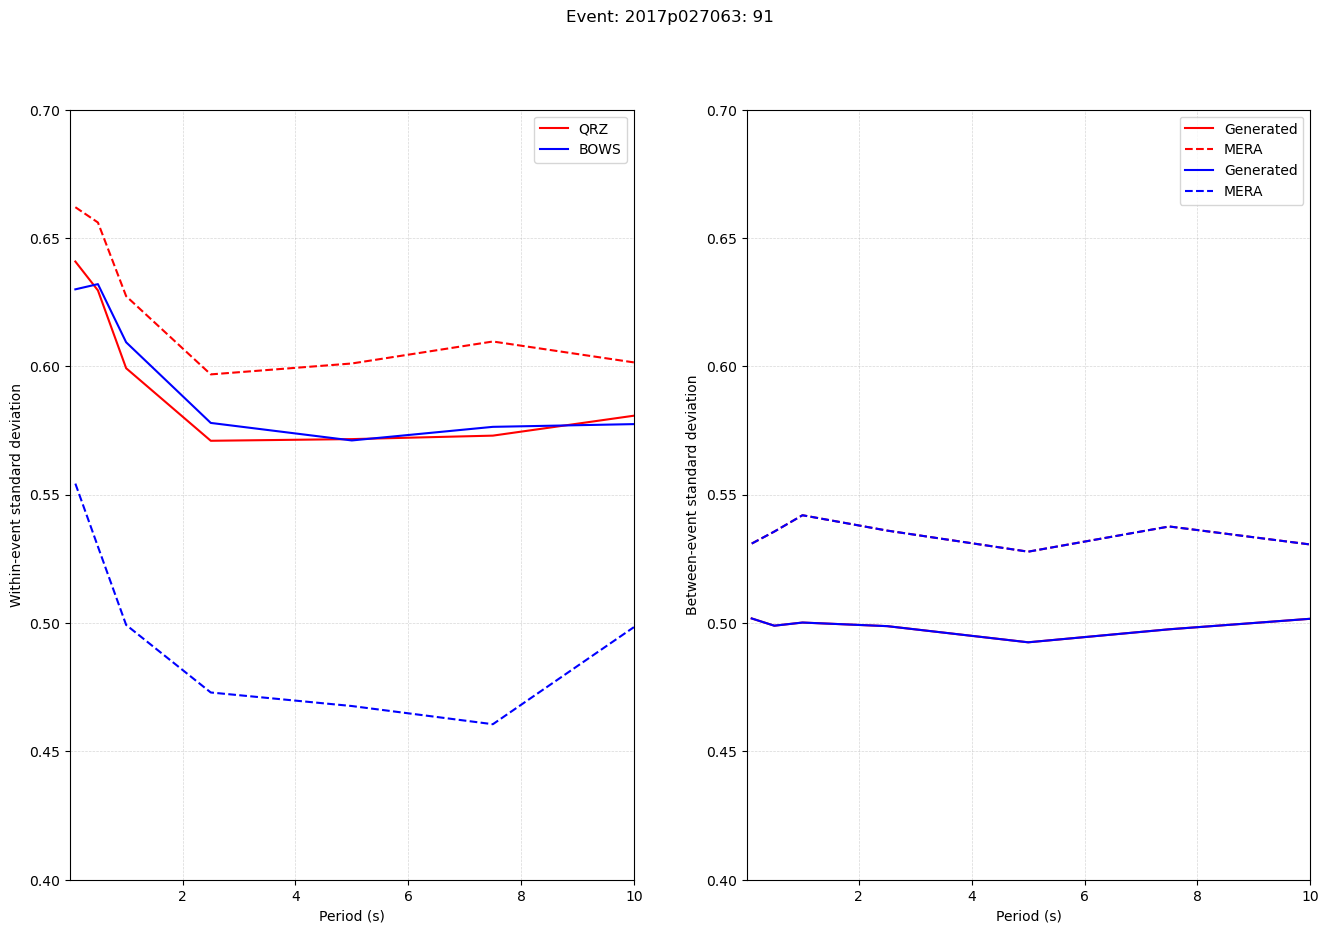

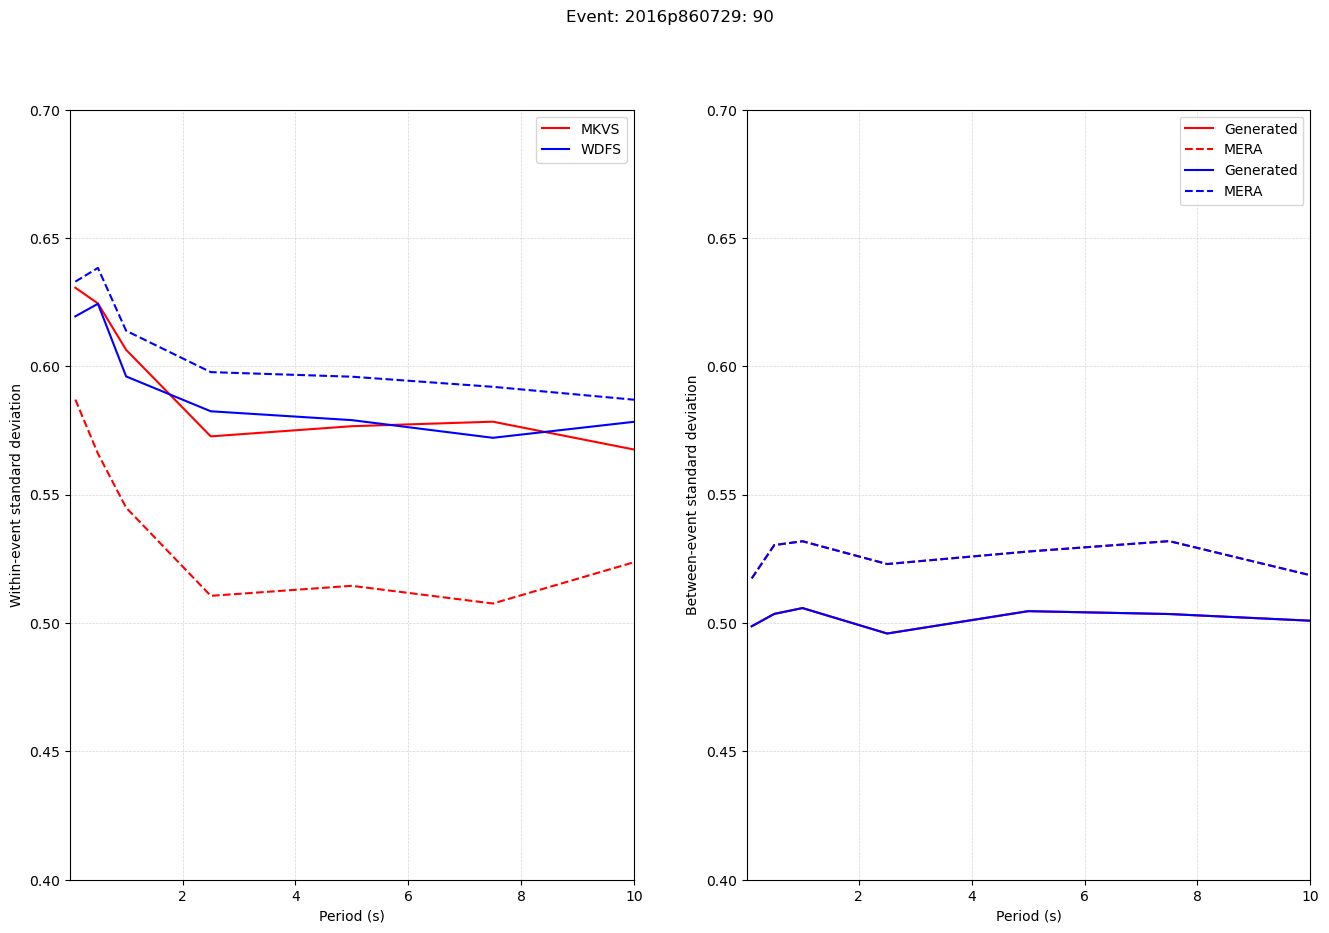

In [7]:
colors = ["r", "b", "g", "y", "c", "m", "k"]

np.random.seed(42)

for cur_event in events:
	cur_gen_dB_std = pd.DataFrame(data=gen_between_values[cur_event].values.std(axis=0), index=ims, columns=gen_between_values[cur_event].labels["site"]).T
	cur_gen_dW_std = pd.DataFrame(data=gen_within_values[cur_event].values.std(axis=0), index=ims, columns=gen_within_values[cur_event].labels["site"]).T
	
	cur_mera_dB_std = mera_event_results[cur_event].std(axis=0)
	cur_mera_dW_std = pd.DataFrame(data=mera_within_results[cur_event].values.std(axis=0), columns=ims, index=mera_within_results[cur_event].labels["site"])
	
	cur_sites = np.random.choice(cur_gen_dB_std.index.values.astype(str), 2, replace=False)
	
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
	
	for cur_color, cur_site in zip(colors, cur_sites):
		ax1.plot(sub_periods, cur_gen_dW_std.loc[cur_site, sub_ims], label=cur_site, c=cur_color, linestyle="-")
		ax1.plot(sub_periods, cur_mera_dW_std.loc[cur_site, sub_ims], c=cur_color, linestyle="--")
		
		ax2.plot(sub_periods, cur_gen_dB_std.loc[cur_site, sub_ims], label="Generated", c=cur_color, linestyle="-")
		ax2.plot(sub_periods, cur_mera_dB_std.loc[sub_ims], label="MERA", c=cur_color, linestyle="--")
	
	ax1.set_xlim([0.01, 10])
	ax1.set_ylim([0.4, 0.7])
	ax1.set_xlabel(f"Period (s)")
	ax1.set_ylabel(f"Within-event standard deviation")
	ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax1.legend()
	
	
	ax2.set_ylim([0.4, 0.7])
	ax2.set_xlim([0.01, 10])
	ax2.set_xlabel(f"Period (s)")
	ax2.set_ylabel(f"Between-event standard deviation")
	ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax2.legend()
	
	fig.suptitle(f"Event: {cur_event}: {cur_gen_dB_std.index.size}")

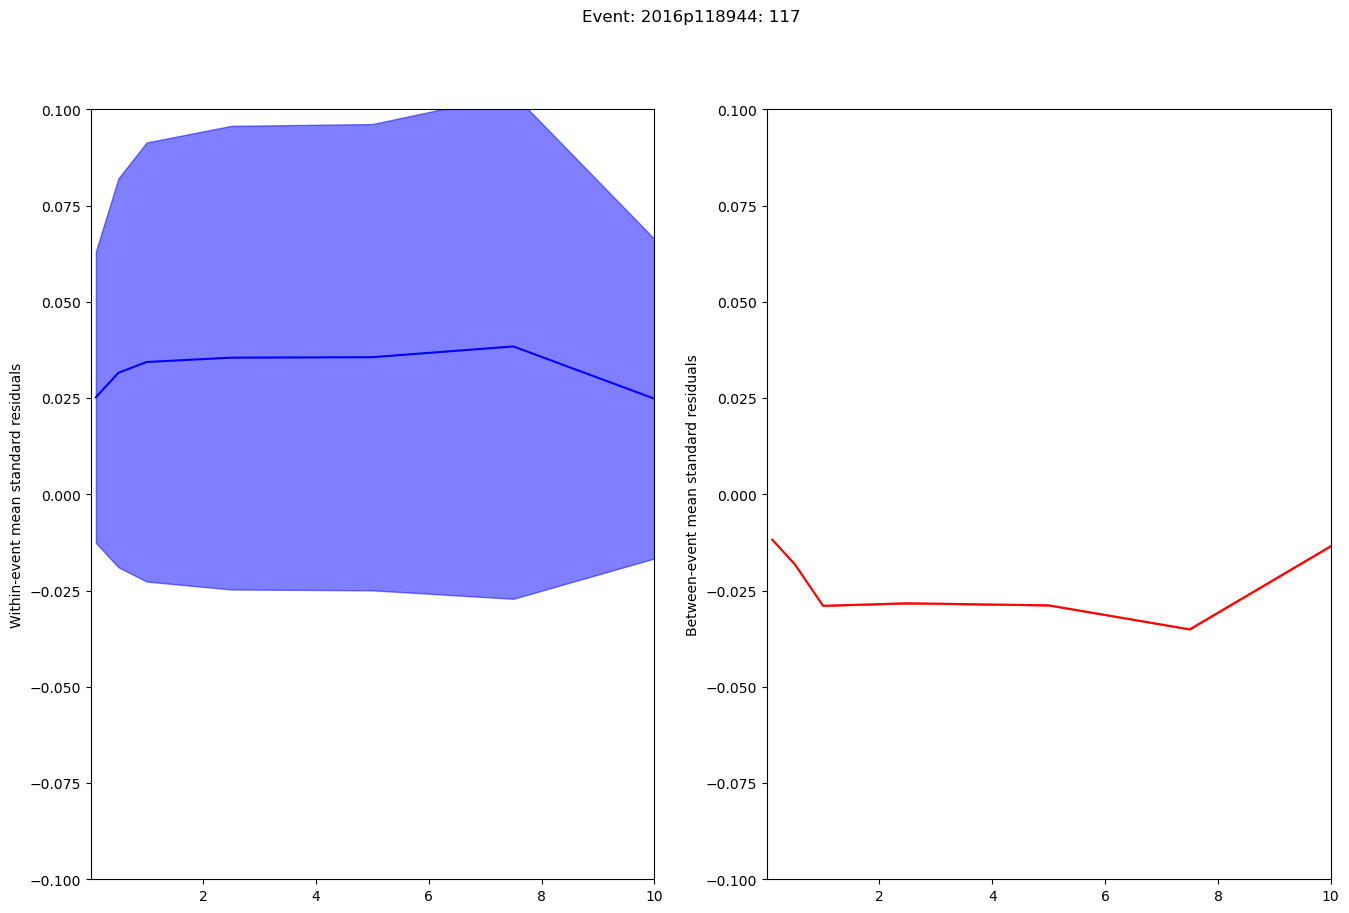

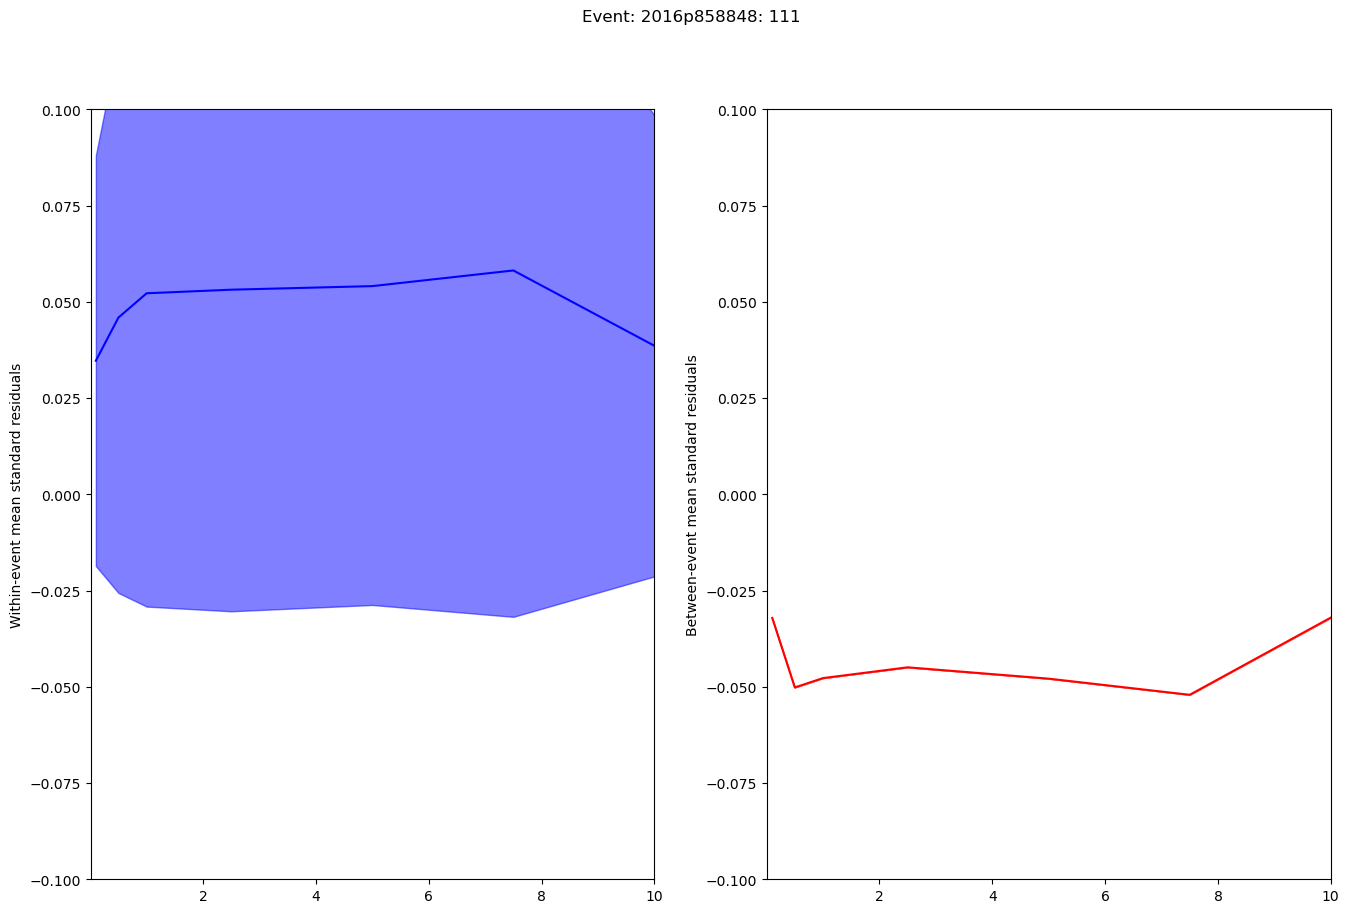

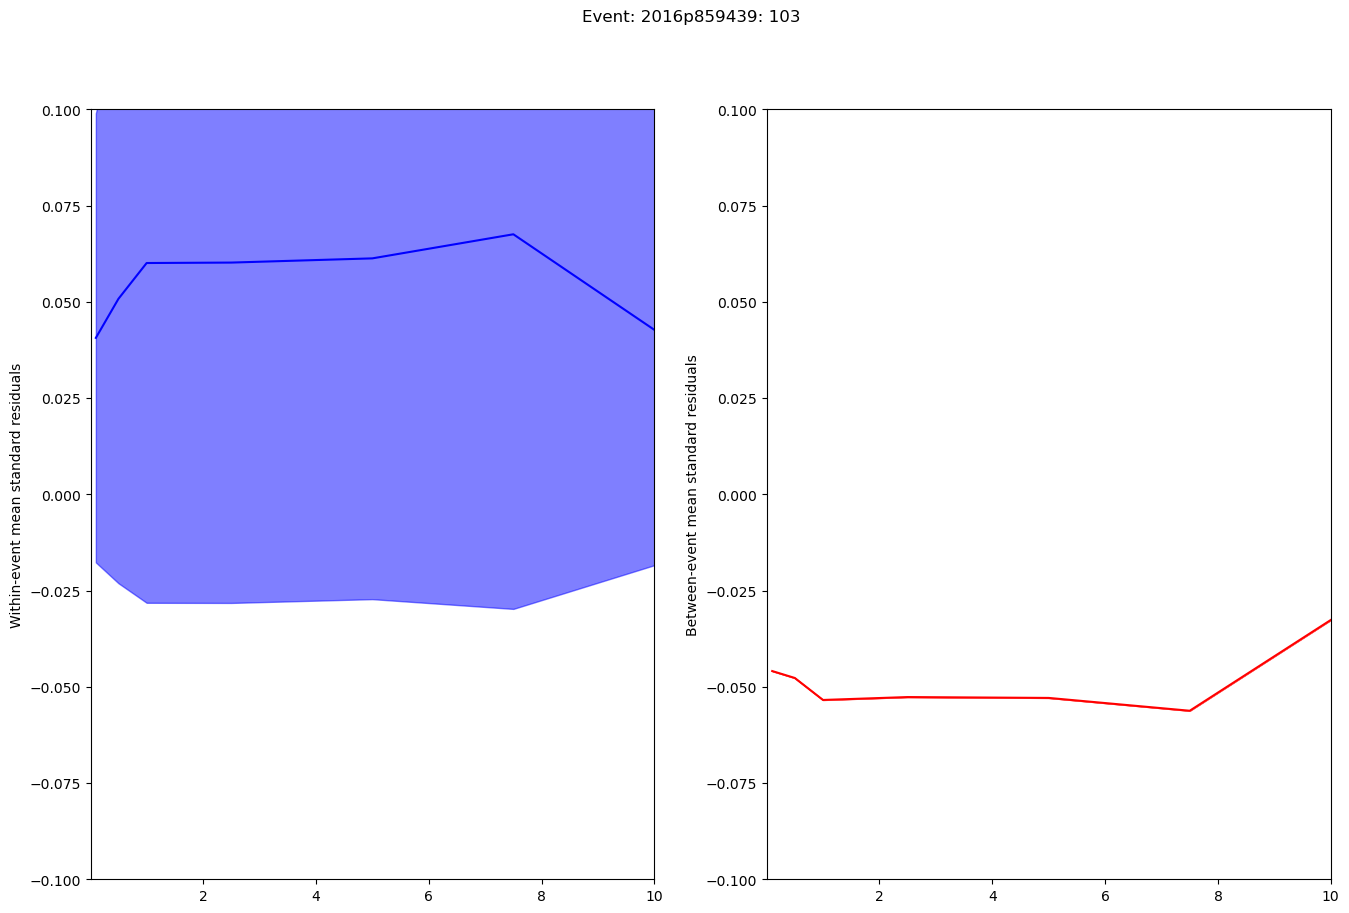

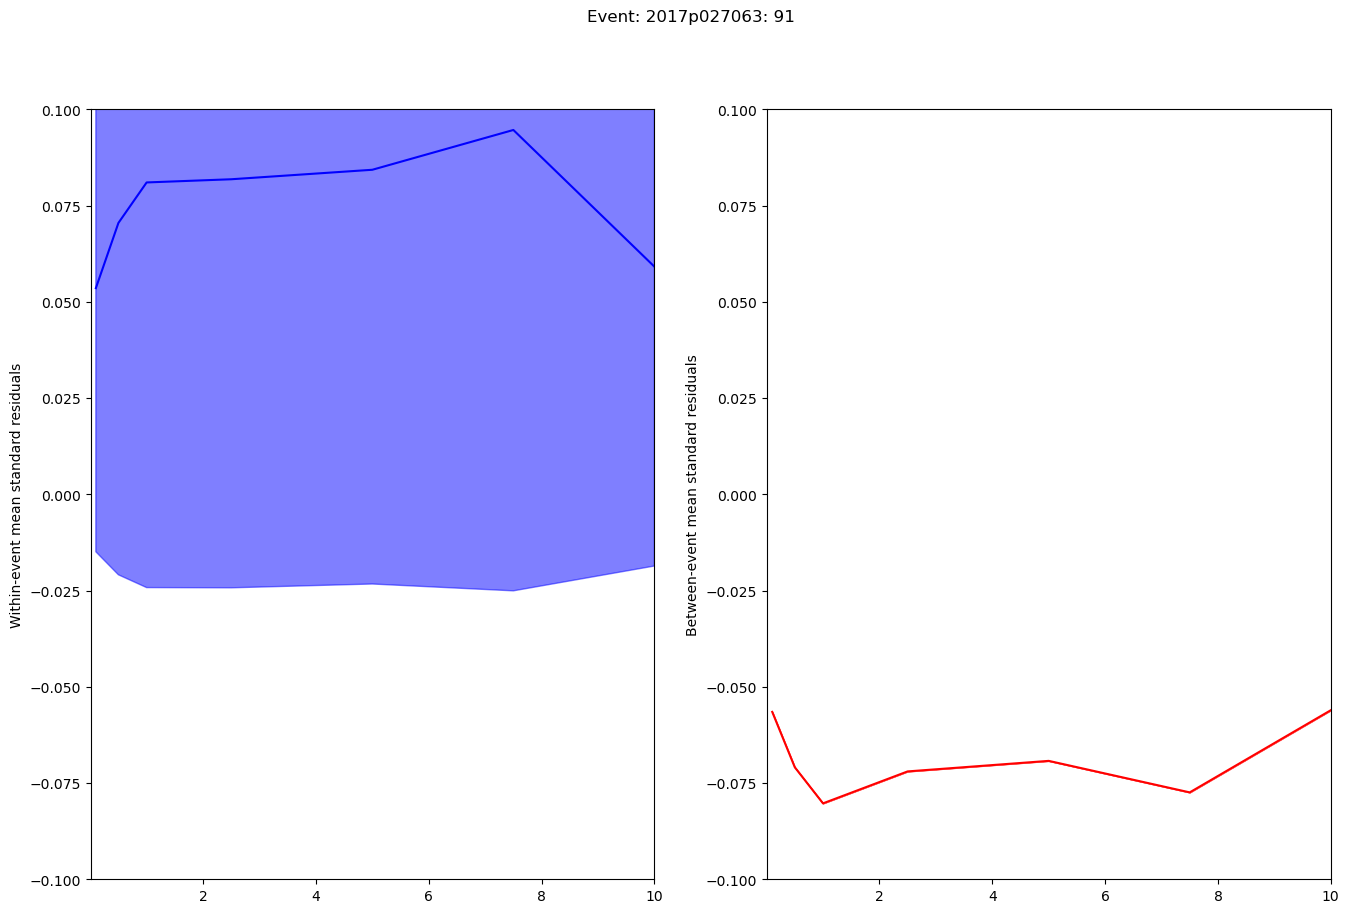

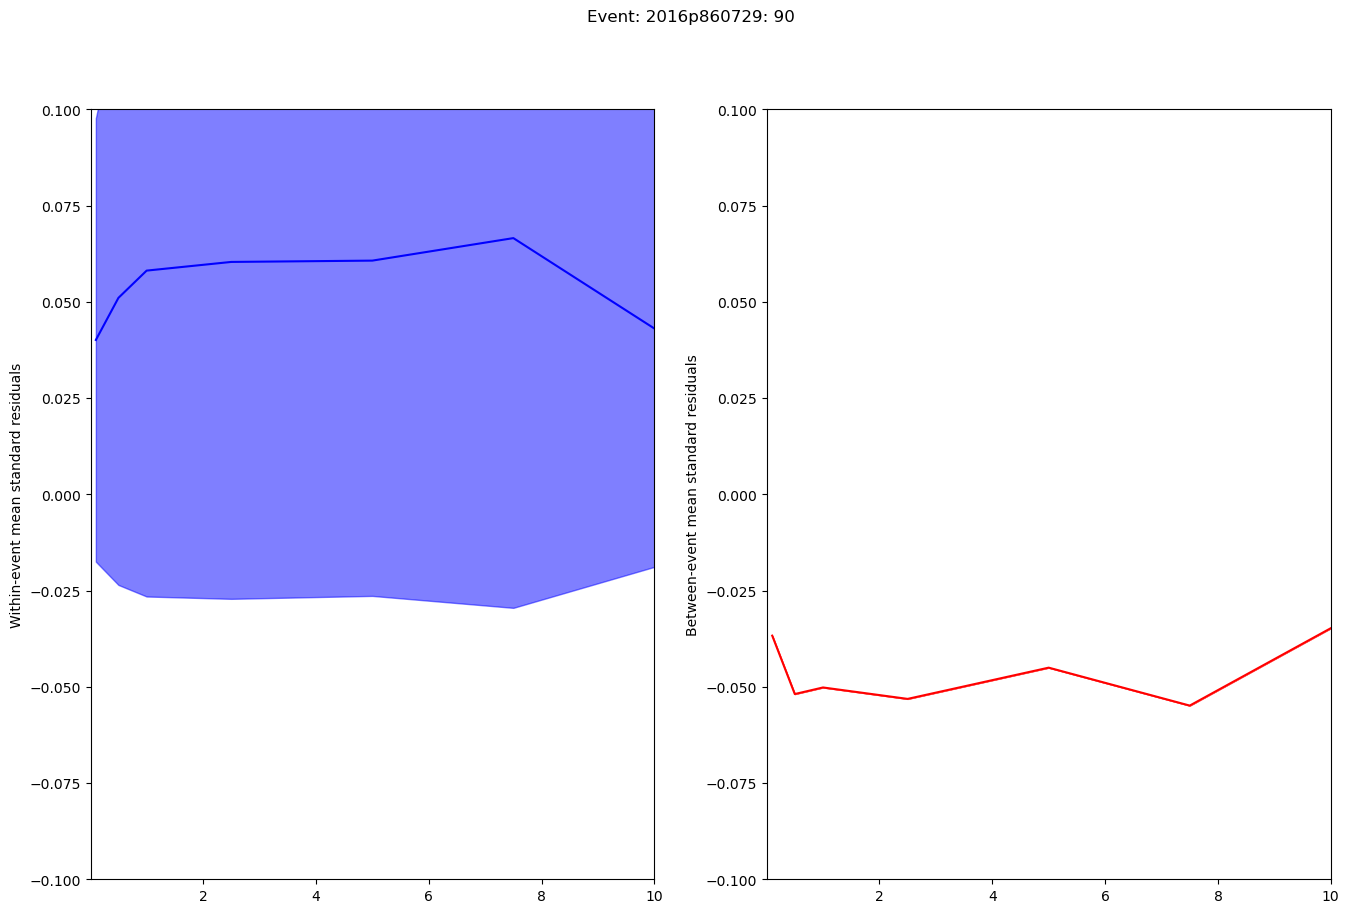

In [8]:
# Compute the average std residual per event
for cur_event in events:
	cur_gen_dB_std = pd.DataFrame(data=gen_between_values[cur_event].values.std(axis=0), index=ims, columns=gen_between_values[cur_event].labels["site"]).T
	cur_gen_dW_std = pd.DataFrame(data=gen_within_values[cur_event].values.std(axis=0), index=ims, columns=gen_within_values[cur_event].labels["site"]).T
	
	cur_mera_dB_std = mera_event_results[cur_event].std(axis=0)
	cur_mera_dW_std = pd.DataFrame(data=mera_within_results[cur_event].values.std(axis=0), columns=ims, index=mera_within_results[cur_event].labels["site"])
	
	db_res = np.log(cur_gen_dB_std.values) - np.log(cur_mera_dB_std.values)
	dw_res = np.log(cur_gen_dW_std) - np.log(cur_mera_dW_std)
	
	db_res_mean = db_res.mean(axis=0)
	db_res_std = db_res.std(axis=0)
	
	dw_res_mean = dw_res.mean(axis=0)
	dw_res_std = dw_res.std(axis=0)
	
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
	
	ax1.plot(sub_periods, dw_res_mean.loc[sub_ims], c="b", linestyle="-")
	ax1.fill_between(sub_periods, dw_res_mean.loc[sub_ims] - dw_res_std.loc[sub_ims], dw_res_mean.loc[sub_ims] + dw_res_std.loc[sub_ims], color="b", alpha=0.5)
	ax1.set_xlim([0.01, 10])
	ax1.set_ylim([-0.1, 0.1])
	ax1.set_ylabel("Within-event mean standard residuals")
	
	ax2.plot(sub_periods, db_res_mean, c="r", linestyle="-")
	ax2.fill_between(sub_periods, db_res_mean - db_res_std, db_res_mean + db_res_std, color="r", alpha=0.5)
	ax2.set_xlim([0.01, 10])
	ax2.set_ylim([-0.1, 0.1])
	ax2.set_ylabel("Between-event mean standard residuals")
	
	fig.suptitle(f"Event: {cur_event}: {cur_gen_dB_std.index.size}")
	

In [9]:
cur_mera_dW_std

,pSA_0.1,pSA_0.5,pSA_1.0,pSA_2.5,pSA_5.0,pSA_7.5,pSA_10.0
AKCZ,0.652130,0.645808,0.625674,0.600574,0.598089,0.601486,0.594452
ARKS,0.571334,0.553210,0.515911,0.490301,0.483489,0.482406,0.509787
BMTS,0.571886,0.549336,0.509737,0.483074,0.478712,0.480709,0.504286
BOWS,0.573182,0.548373,0.510229,0.495503,0.487729,0.478465,0.517303
CAW,0.597897,0.588145,0.560415,0.532607,0.528976,0.522707,0.539458
...,...,...,...,...,...,...,...
WEL,0.583474,0.549816,0.523990,0.496091,0.485842,0.491463,0.510976
WEMS,0.569176,0.547202,0.512358,0.495012,0.487428,0.480407,0.512208
WNAS,0.581085,0.567514,0.538243,0.514560,0.507430,0.503177,0.525493
WNKS,0.576092,0.559680,0.533391,0.501954,0.500636,0.495352,0.524478
